In [151]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef, cohen_kappa_score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

In [152]:
drop_cols= ['account_age_days', 'multiple_transactions_short_time', 'account_age_days_log', 'avg_transaction_amount_7d_log',
'transaction_amount_log', 'payment_method_Apple Pay', 'payment_method_Credit Card', 'payment_method_Debit Card',
'payment_method_Google Pay', 'payment_method_PayPal', 'device_type_console', 'device_type_desktop', 
'device_type_mobile', 'device_type_smart tv', 'device_type_tablet', 'device_type_wearable', 
'location_australia', 'location_canada', 'location_india', 'location_united kingdom', 
'location_unknown region', 'location_usa', 'merchant_category_antiques', 'merchant_category_collectibles', 
'merchant_category_electronics', 'merchant_category_gaming', 'merchant_category_groceries', 'merchant_category_luxury',
'merchant_category_private seller', 'merchant_category_restaurants', 'merchant_category_travels']

In [153]:
def fit_train_stats(X_train):
    stats= {
        "transaction_amount": X_train["transaction_amount"].median(),
        "transaction_frequency_24h": X_train["transaction_frequency_24h"].median(),
        "avg_transaction_amount_7d": X_train["avg_transaction_amount_7d"].median(),
        "failed_transaction_count_24h": X_train["failed_transaction_count_24h"].median(),
        "account_age_days": X_train["account_age_days"].median(),
        "payment_method": X_train["payment_method"].mode()[0],
        "device_type": X_train["device_type"].mode()[0],
        "location": X_train["location"].mode()[0],
        "is_international": X_train["is_international"].mode()[0],
        "merchant_category": X_train["merchant_category"].mode()[0],
        "unusual_amount_flag": X_train["unusual_amount_flag"].mode()[0],
        "multiple_transactions_short_time": X_train["multiple_transactions_short_time"].mode()[0],
        "high_risk_device_flag": X_train["high_risk_device_flag"].mode()[0],
    }
    return stats

In [154]:
def handle_null(df, stats):
    df["transaction_amount"]= df["transaction_amount"].fillna(stats["transaction_amount"])
    df["transaction_frequency_24h"]= df["transaction_frequency_24h"].fillna(stats["transaction_frequency_24h"])
    df["avg_transaction_amount_7d"]= df["avg_transaction_amount_7d"].fillna(stats["avg_transaction_amount_7d"])
    df["failed_transaction_count_24h"]= df["failed_transaction_count_24h"].fillna(stats["failed_transaction_count_24h"])
    df["account_age_days"]= df["account_age_days"].fillna(stats["account_age_days"])
    df["payment_method"]= df["payment_method"].fillna(stats["payment_method"])
    df["device_type"]= df["device_type"].fillna(stats["device_type"])
    df["location"]= df["location"].fillna(stats["location"])
    df["is_international"]= df["is_international"].fillna(stats["is_international"])
    df["merchant_category"]= df["merchant_category"].fillna(stats["merchant_category"])
    df["unusual_amount_flag"]= df["unusual_amount_flag"].fillna(stats["unusual_amount_flag"])
    df["multiple_transactions_short_time"]= df["multiple_transactions_short_time"].fillna(stats["multiple_transactions_short_time"])
    df["high_risk_device_flag"]= df["high_risk_device_flag"].fillna(stats["high_risk_device_flag"])
    return df

In [155]:
def transaction_amount_handler(df):
    df["transaction_amount"]= df["transaction_amount"].replace({"not_available": np.nan, "unknown": np.nan})
    df["transaction_amount"]= pd.to_numeric(df["transaction_amount"], errors="coerce")
    df.loc[df["transaction_amount"] <= 0, "transaction_amount"]=np.nan
    return df

In [156]:
def payment_method_handler(df):
    m={
        "applepay": "apple pay", "apple_pay": "apple pay",
        "gooogle pay": "google pay", "google_pay": "google pay", "googlepay": "google pay",
        "creditcard": "credit card", "credit_card": "credit card", "credt card": "credit card",
        "debitcard": "debit card", "debit_card": "debit card", "debiit card": "debit card",
        "pay pal": "paypal", "pay_pal": "paypal", "paypall": "paypal",
    }
    df["payment_method"]= df["payment_method"].replace(m)
    return df

In [157]:
def device_type_handler(df):
  df["device_type"]= df["device_type"].astype("string").str.lower().str.strip()
  m= {
      "desktop_pc": "desktop",
      "desk top": "desktop",
      "tabelt": "tablet",
      "tab let": "tablet",
      "moblie": "mobile",
      "desktp": "desktop",
      "tablet_device": "tablet"
      }
  df["device_type"]= df["device_type"].replace(m)
  return df

In [158]:
def location_handler(df):
  df["location"]=(df["location"].str.strip().str.lower())
  m= {
      "uk": "united kingdom",
      "untied kingdom": "united kingdom",
      "u.k": "united kingdom",
      "u.k.": "united kingdom",
      "au": "australia",
      "australia": "australia",
      "austraila": "australia",
      "us": "usa",
      "u.s.a.": "usa",
      "indai": "india",
      "in": "india",
      "canadaa": "canada",
      "atlantis": "unknown region",
      "mars colony": "unknown region",
      "ca": "canada"
      }
  df["location"]= df["location"].replace(m)
  return df

In [159]:
def merchant_category_handler(df):
    df["merchant_category"]=df["merchant_category"].str.strip().str.lower()
    m={
        "fashoin": "fashion", "fashon": "fashion",
        "groceriez": "groceries", "grocery": "groceries",
        "electornics": "electronics", "electronic": "electronics",
        "gameing": "gaming",
        "restaraunts": "restaurants",
        "travels": "travel",
    }
    df["merchant_category"]= df["merchant_category"].replace(m)
    return df

In [160]:
def is_international_handler(df):
    df["is_international"]= df["is_international"].astype(str).str.strip().str.lower()
    m={"true": 1, "false": 0, "yes": 1, "no": 0, "y": 1, "n": 0, "1": 1, "0": 0}
    df["is_international"]= df["is_international"].replace(m)
    df["is_international"]= pd.to_numeric(df["is_international"], errors="coerce")
    return df

In [161]:
def transaction_frequency_24h_handler(df):
    df["transaction_frequency_24h"]= df["transaction_frequency_24h"].replace({"many": 249, "unknown": np.nan})
    df["transaction_frequency_24h"]= pd.to_numeric(df["transaction_frequency_24h"], errors="coerce")
    df.loc[df["transaction_frequency_24h"] < 0, "transaction_frequency_24h"]=np.nan
    return df

In [162]:
def avg_transaction_amount_7d_handler(df):
    df["avg_transaction_amount_7d"]= df["avg_transaction_amount_7d"].replace({"missing": np.nan, "unknown": np.nan})
    df["avg_transaction_amount_7d"]= pd.to_numeric(df["avg_transaction_amount_7d"], errors="coerce")
    df.loc[df["avg_transaction_amount_7d"] < 0, "avg_transaction_amount_7d"]= np.nan
    return df

In [163]:
def failed_transaction_count_24h_handler(df):
    df["failed_transaction_count_24h"]= df["failed_transaction_count_24h"].replace({"none": np.nan, "unknown": np.nan})
    df["failed_transaction_count_24h"]= pd.to_numeric(df["failed_transaction_count_24h"], errors="coerce")
    df.loc[df["failed_transaction_count_24h"] < 0, "failed_transaction_count_24h"]=np.nan
    return df

In [164]:
def account_age_days_handler(df):
    df["account_age_days"]= df["account_age_days"].replace({"new_user?": np.nan, "unknown": np.nan})
    df["account_age_days"]= pd.to_numeric(df["account_age_days"], errors="coerce")
    df.loc[df["account_age_days"] < 0, "account_age_days"]= np.nan
    return df

In [165]:
def unusual_amount_flag_handler(df):
    df["unusual_amount_flag"]= df["unusual_amount_flag"].astype(str).str.strip().str.lower()
    m={"true": 1, "false": 0, "yes": 1, "no": 0, "y": 1, "n": 0, "1": 1, "0": 0}
    df["unusual_amount_flag"]= df["unusual_amount_flag"].replace(m)
    df["unusual_amount_flag"]= pd.to_numeric(df["unusual_amount_flag"], errors="coerce")
    return df

In [166]:
def multiple_transactions_short_time_handler(df):
    df["multiple_transactions_short_time"]= df["multiple_transactions_short_time"].astype(str).str.strip().str.lower()
    m={"true": 1, "false": 0, "yes": 1, "no": 0, "y": 1, "n": 0, "1": 1, "0": 0}
    df["multiple_transactions_short_time"]= df["multiple_transactions_short_time"].replace(m)
    df["multiple_transactions_short_time"]= pd.to_numeric(df["multiple_transactions_short_time"], errors="coerce")
    return df

In [167]:
def high_risk_device_flag_handler(df):
    df["high_risk_device_flag"]= df["high_risk_device_flag"].astype(str).str.strip().str.lower()
    m={"true": 1, "false": 0, "yes": 1, "no": 0, "y": 1, "n": 0, "1": 1, "0": 0}
    df["high_risk_device_flag"]= df["high_risk_device_flag"].replace(m)
    df["high_risk_device_flag"]= pd.to_numeric(df["high_risk_device_flag"], errors="coerce")
    return df

In [168]:
def clean_df(df):
    df= df.copy()
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col]= df[col].astype(str).str.strip().str.lower()
    df= df.drop(columns=[c for c in ["customer_id", "transaction_timestamp", "transaction_id", "id", "label"] if c in df.columns])
    
    df= transaction_amount_handler(df)
    df= transaction_frequency_24h_handler(df)
    df= avg_transaction_amount_7d_handler(df)
    df= failed_transaction_count_24h_handler(df)
    df= account_age_days_handler(df)
    df= payment_method_handler(df)
    df= device_type_handler(df)
    df= location_handler(df)
    df= merchant_category_handler(df)
    df= is_international_handler(df)
    df= unusual_amount_flag_handler(df)
    df= multiple_transactions_short_time_handler(df)
    df= high_risk_device_flag_handler(df)
    return df

In [169]:
def advanced_feature_eng(df, train_df=None, stats=None, has_label=False):
    df=df.copy()
    if train_df is None:
        train_df= df
    if stats is None:
        stats= {}
        stats["amount_mean"]= train_df["transaction_amount"].mean()
        stats["amount_std"]= train_df["transaction_amount"].std() + 1e-5
        stats["amount_p95"]=train_df["transaction_amount"].quantile(0.95)
        stats["amount_p05"]= train_df["transaction_amount"].quantile(0.05)
        stats["amount_p75"]= train_df["transaction_amount"].quantile(0.75)
        stats["amount_p25"]= train_df["transaction_amount"].quantile(0.25)
        
        stats["freq_mean"]= train_df["transaction_frequency_24h"].mean()
        stats["freq_std"]= train_df["transaction_frequency_24h"].std() + 1e-5
        stats["freq_p75"]=train_df["transaction_frequency_24h"].quantile(0.75)

        stats["avg_7d_mean"]= train_df["avg_transaction_amount_7d"].mean()
        stats["avg_7d_std"]=train_df["avg_transaction_amount_7d"].std() + 1e-5
        
        stats["age_mean"]= train_df["account_age_days"].mean()
        stats["age_std"]=train_df["account_age_days"].std() + 1e-5

    df["transaction_amount_log"]= np.log1p(df["transaction_amount"])
    df["account_age_days_log"]=np.log1p(df["account_age_days"])
    df["avg_transaction_amount_7d_log"]= np.log1p(df["avg_transaction_amount_7d"])
    df["transaction_frequency_24h_log"]=np.log1p(df["transaction_frequency_24h"])

    df["amount_zscore"]= np.abs((df["transaction_amount"] - stats["amount_mean"]) / stats["amount_std"])
    df["freq_zscore"]= np.abs((df["transaction_frequency_24h"] - stats["freq_mean"]) / stats["freq_std"])
    df["age_zscore"]=np.abs((df["account_age_days"] - stats["age_mean"]) / stats["age_std"])

    df["amount_vs_avg_7d"]= (df["transaction_amount"] - df["avg_transaction_amount_7d"]) / (stats["avg_7d_std"] + 1)
    df["amount_vs_avg_7d_ratio"]= df["transaction_amount"] / (df["avg_transaction_amount_7d"] + 1)
    df["high_value_transaction"]= (df["transaction_amount"] > stats["amount_p95"]).astype(int)
    df["low_value_transaction"]=(df["transaction_amount"] < stats["amount_p05"]).astype(int)
    df["mid_range_transaction"]= ((df["transaction_amount"] >= stats["amount_p25"]) & 
                                   (df["transaction_amount"] <= stats["amount_p75"])).astype(int)
    df["amount_exceeds_7d_2x"]= (df["transaction_amount"] > 2 * df["avg_transaction_amount_7d"]).astype(int)

    df["high_frequency"]= (df["transaction_frequency_24h"] > stats["freq_p75"]).astype(int)
    df["very_high_frequency"]= (df["transaction_frequency_24h"] > 20).astype(int)
    df["high_frequency_with_failures"]=df["high_frequency"] * (df["failed_transaction_count_24h"] > 0).astype(int)

    df["failure_rate"]= df["failed_transaction_count_24h"] / (df["transaction_frequency_24h"] + 1)
    df["has_failures"]=(df["failed_transaction_count_24h"] > 0).astype(int)
    df["high_failure_rate"]= (df["failure_rate"] > 0.3).astype(int)
    df["moderate_failure_rate"]=((df["failure_rate"] > 0.1) & (df["failure_rate"] <= 0.3)).astype(int)

    df["risk_score"]=(df["unusual_amount_flag"] + 
                        df["multiple_transactions_short_time"] + 
                        df["high_risk_device_flag"] + 
                        df["is_international"])
    df["multiple_risk_flags"]= (df["risk_score"] >= 2).astype(int)
    df["no_risk_flags"]= (df["risk_score"] == 0).astype(int)
    df["unusual_x_multi"] = df["unusual_amount_flag"] * df["multiple_transactions_short_time"]
    df["unusual_x_device"] = df["unusual_amount_flag"] * df["high_risk_device_flag"]
    df["unusual_x_intl"] = df["unusual_amount_flag"] * df["is_international"]
    df["device_x_intl"] = df["high_risk_device_flag"] * df["is_international"]
    df["multi_x_intl"] = df["multiple_transactions_short_time"] * df["is_international"]
    df["all_three_flags"] = ((df["unusual_amount_flag"] == 1) & 
                             (df["multiple_transactions_short_time"] == 1) & 
                             (df["high_risk_device_flag"] == 1)).astype(int)
    
    df["account_age_credibility"] = 1.0 / (1.0 + np.exp(-0.00005 * (df["account_age_days"] - 365)))
    df["very_young_account"] = (df["account_age_days"] < 30).astype(int)
    df["young_account"] = (df["account_age_days"] < 90).astype(int)
    df["new_account"] = (df["account_age_days"] < 365).astype(int)
    df["very_old_account"] = (df["account_age_days"] > 10000).astype(int)
    
    df["young_high_value"] = df["new_account"] * df["high_value_transaction"]
    df["young_with_failures"] = df["new_account"] * df["has_failures"]
    df["young_with_risks"] = df["new_account"] * df["multiple_risk_flags"]
    df["old_account_credibility_score"] = df["account_age_credibility"] * df["risk_score"]
    
    df["anomaly_score"] = (df["amount_zscore"] + df["freq_zscore"] + df["failure_rate"] + df["risk_score"]) / 4
    
    df["international_high_value"] = df["is_international"] * df["high_value_transaction"]
    df["international_with_risks"] = df["is_international"] * df["multiple_risk_flags"]
    
    df["amount_per_age_years"] = df["transaction_amount"] / (df["account_age_days"] / 365.0 + 1)
    df["freq_per_age_years"] = df["transaction_frequency_24h"] / (df["account_age_days"] / 365.0 + 1)
    df["avg_transaction_per_freq"] = df["avg_transaction_amount_7d"] / (df["transaction_frequency_24h"] + 1)
    
    df = pd.get_dummies(df, columns=["payment_method", "device_type", "location", "merchant_category"], 
                       dtype=int, drop_first=False)
    
    return df, stats

In [ ]:
df = pd.read_excel("task 1 - datasets/train.xlsx")
df = df.sort_values("transaction_timestamp")

In [ ]:
df.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,unusual_amount_flag,multiple_transactions_short_time,high_risk_device_flag,label
0,T0000429,C18117,2025-04-30 19:56:23.688247,209.35,PayPal,Mobile,Canada,Groceries,true,14,100.5,3,1499,Y,true,N,1
1,T0000802,C12701,2025-04-30 19:56:23.696115,330.37,Google Pay,Mobile,Canada,Electronics,no,9,101.05,0,1683,Y,true,no,0
2,T0001022,C16921,2025-04-30 19:56:23.700517,140.7,PayPal,Tablet,Australia,Travel,FALSE,14,NaN,0,1058,yes,yes,N,1
3,T0001056,C22487,2025-04-30 19:56:23.701177,0.65,PayPal,Desktop,Germany,Travel,N,6,97.23,3,1826,false,0,false,0
4,T0001217,C07940,2025-04-30 19:56:23.704498,230.28,Debit Card,Mobile,India,Electronics,1,1,44.73,1,512,Y,N,Y,1


In [ ]:
missing= df.isnull().sum()
missing_pct= (missing/len(df)*100).round(2)
missing_df= pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df= missing_df[missing_df["Missing Count"]>0].sort_values("Missing %", ascending=False)
print(missing_df)

                              Missing Count  Missing %
avg_transaction_amount_7d              1874       2.34
transaction_amount                     1836       2.30
failed_transaction_count_24h           1425       1.78
account_age_days                       1414       1.77
transaction_frequency_24h              1392       1.74
device_type                             826       1.03
location                                816       1.02
merchant_category                       807       1.01
payment_method                          810       1.01


C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\105544687.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col_data = pd.to_numeric(df[col].replace({"not_available": None, "unknown": None,
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\105544687.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot([legit, fraud], labels=["Legitimate", "Fraudulent"],
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\105544687.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-i

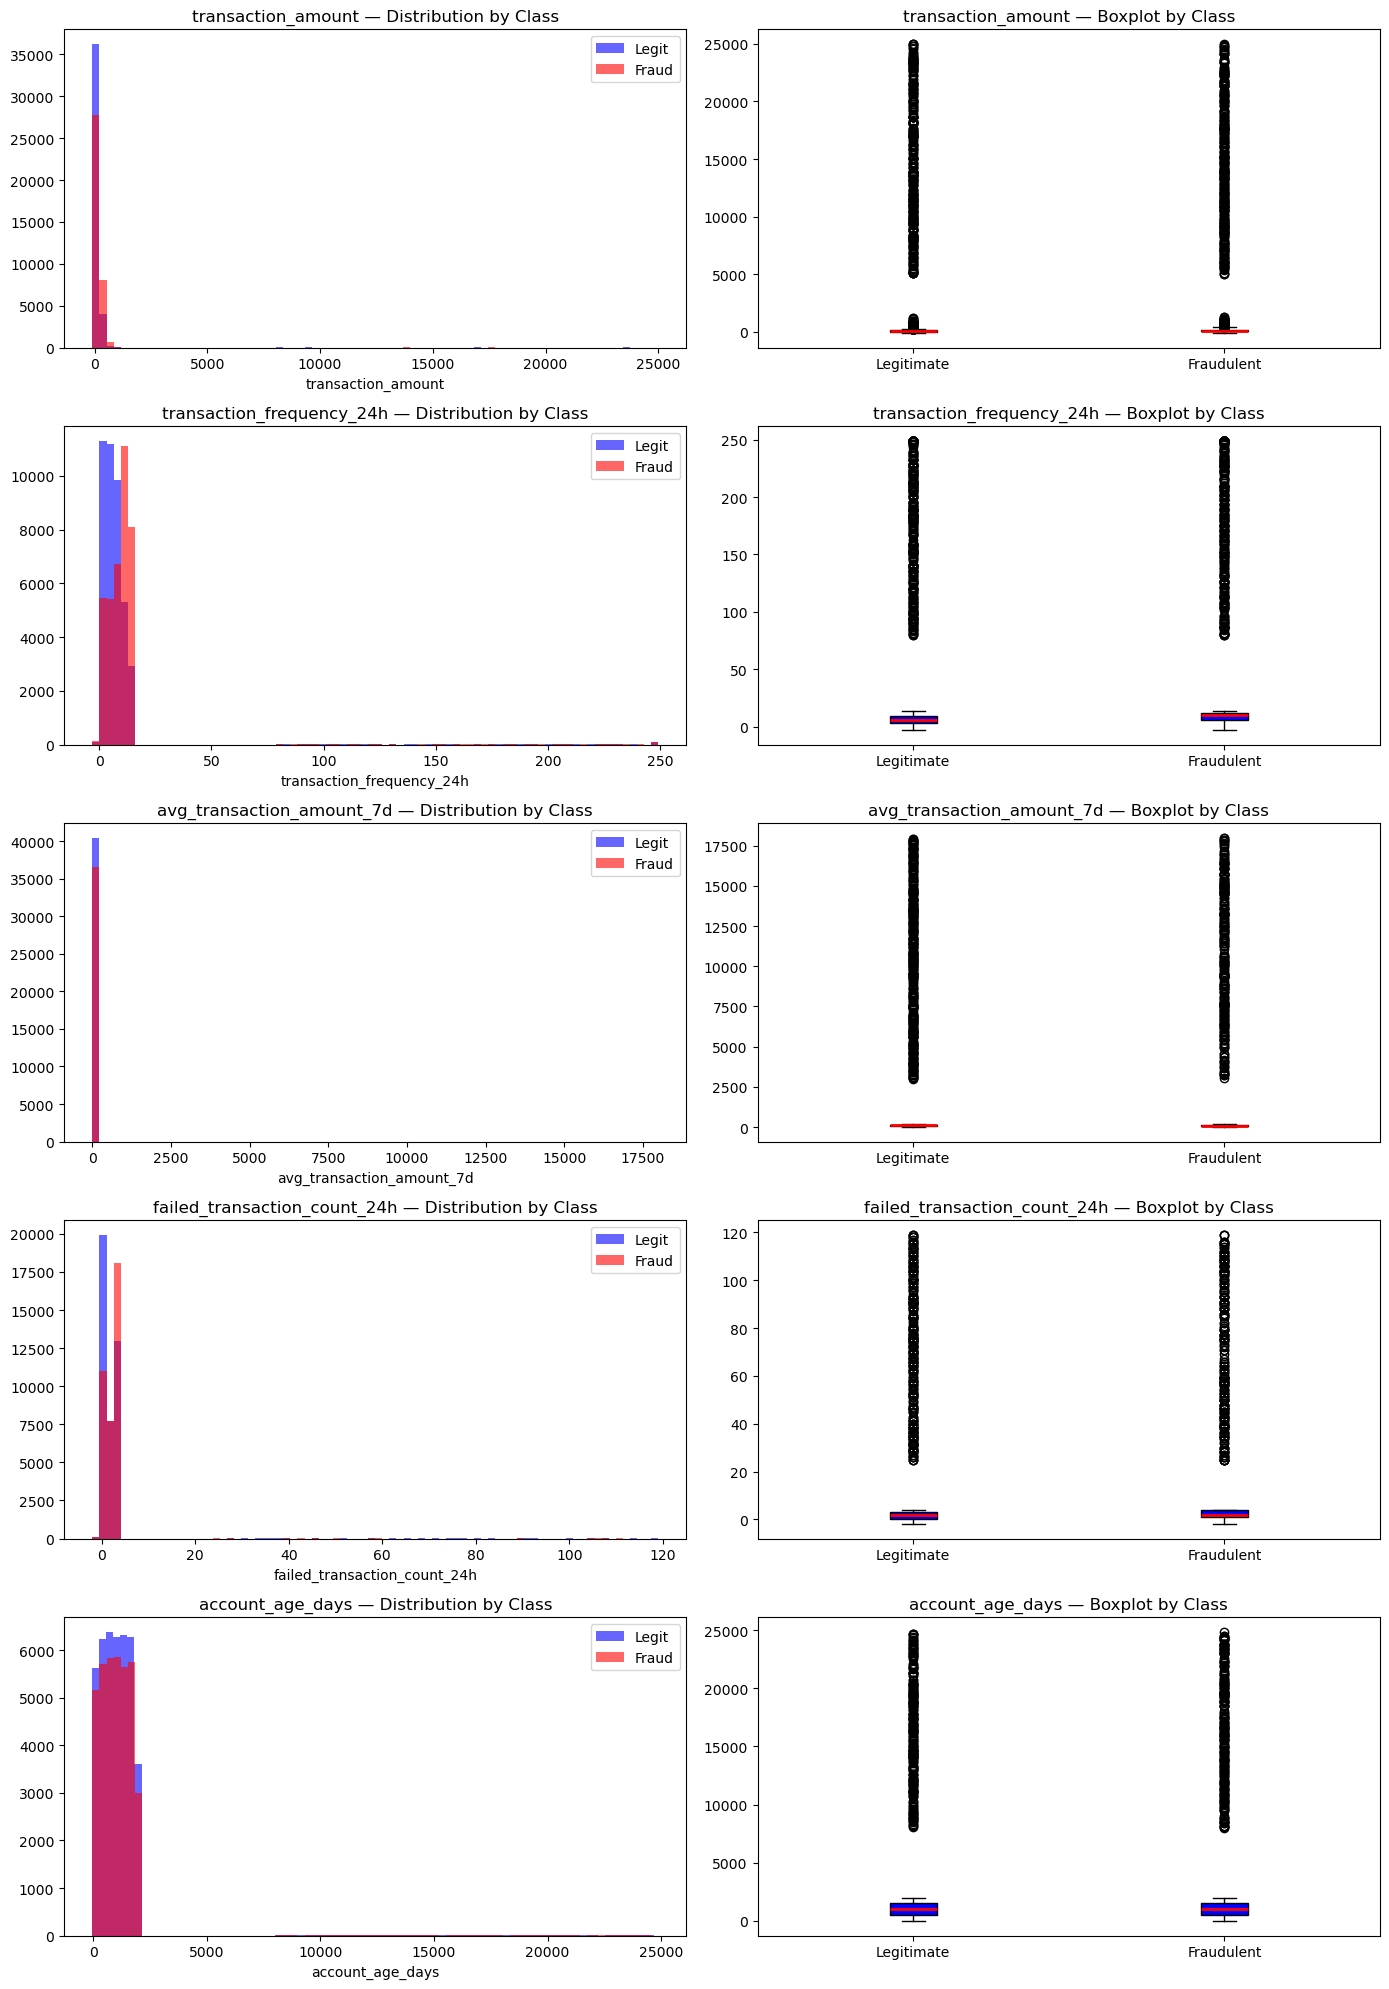

In [ ]:
num_cols=["transaction_amount", "transaction_frequency_24h",
            "avg_transaction_amount_7d", "failed_transaction_count_24h", "account_age_days"]
fig, axes=plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))
for i, col in enumerate(num_cols):
    col_data=pd.to_numeric(df[col].replace({"not_available": None, "unknown": None,
                                               "missing": None, "none": None,
                                               "many": 249, "new_user?": None}), errors="coerce")
    temp= pd.DataFrame({"value": col_data, "label": df["label"]}).dropna()
    for label, color in [(0, "blue"), (1, "red")]:
        axes[i, 0].hist(temp[temp["label"]== label]["value"], bins=80,
                        alpha=0.6, color=color, label=f"{'Legit' if label==0 else 'Fraud'}")
    axes[i, 0].set_title(f"{col} — Distribution by Class")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].legend()
    legit= temp[temp["label"]== 0]["value"]
    fraud= temp[temp["label"]== 1]["value"]
    axes[i, 1].boxplot([legit, fraud], labels=["Legitimate", "Fraudulent"],
                       patch_artist=True,
                       boxprops=dict(facecolor="blue"),
                       medianprops=dict(color="red", linewidth=2))
    axes[i, 1].set_title(f"{col} — Boxplot by Class")

plt.tight_layout()
plt.show()

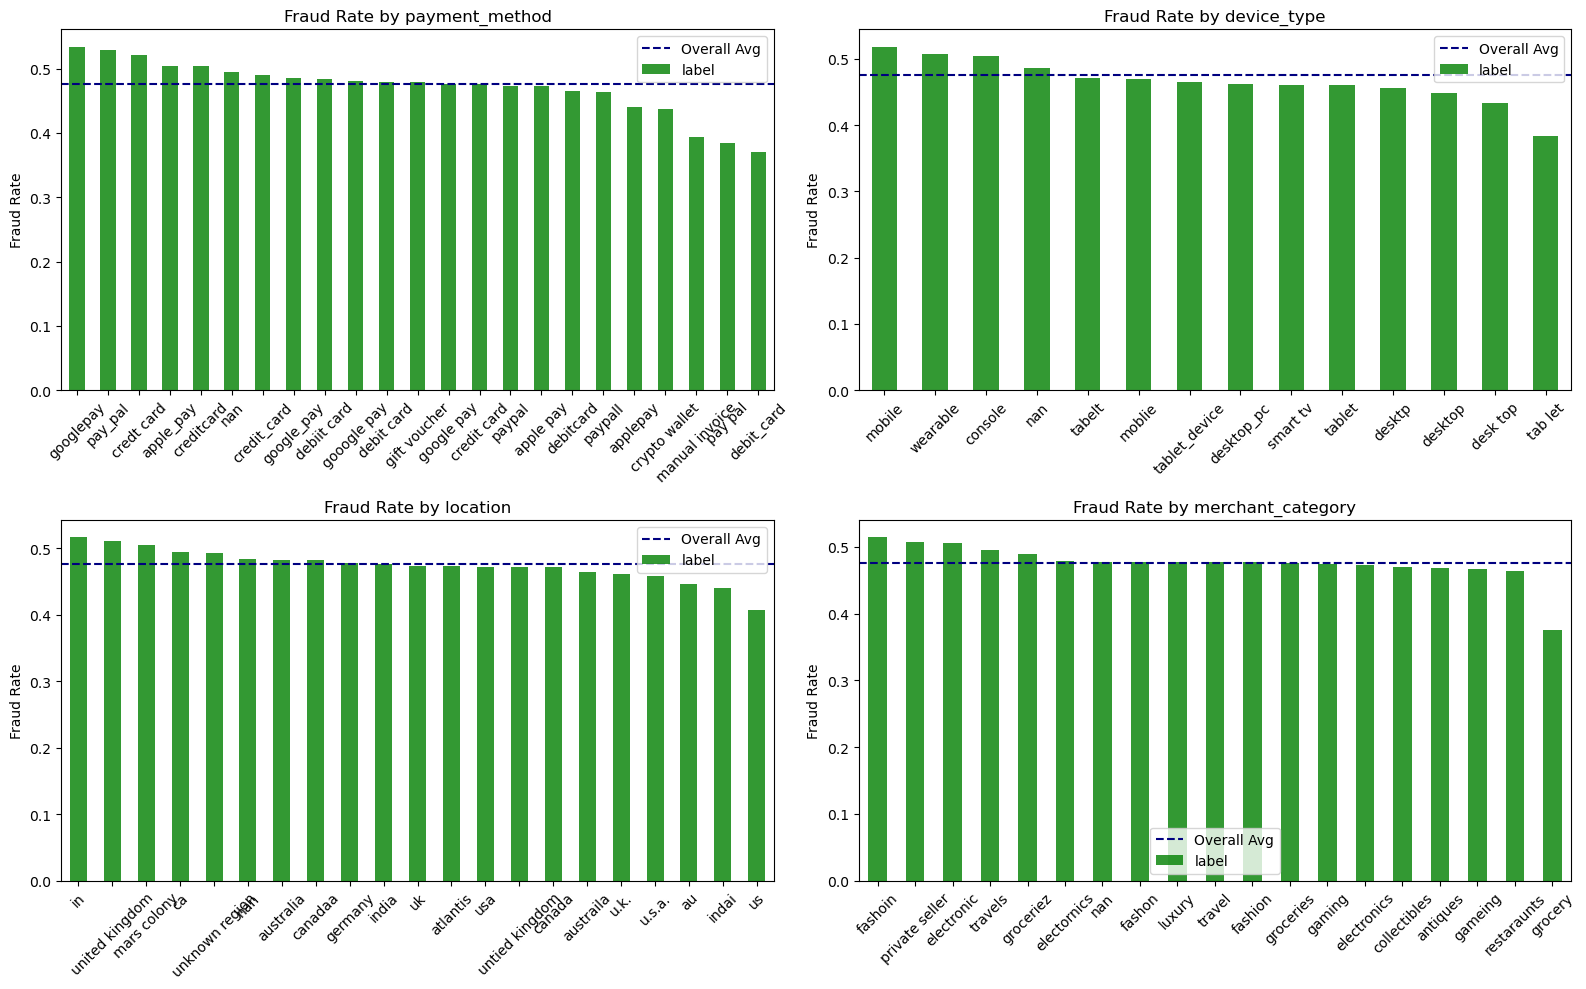

In [ ]:
cat_cols= ["payment_method", "device_type", "location", "merchant_category"]

df_eda=df.copy()
df_eda["payment_method"]=df_eda["payment_method"].astype(str).str.strip().str.lower()
df_eda["device_type"]=df_eda["device_type"].astype(str).str.strip().str.lower()
df_eda["location"]=df_eda["location"].astype(str).str.strip().str.lower()
df_eda["merchant_category"]=df_eda["merchant_category"].astype(str).str.strip().str.lower()

fig, axes=plt.subplots(2, 2, figsize=(16, 10))
axes=axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_rate=df_eda.groupby(col)["label"].mean().sort_values(ascending=False)
    fraud_rate.plot(kind="bar", ax=axes[i], color="green", alpha=0.8)
    axes[i].set_title(f"Fraud Rate by {col}")
    axes[i].set_ylabel("Fraud Rate")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].axhline(df["label"].mean(), color="navy", linestyle="--", label="Overall Avg")
    axes[i].legend()

plt.tight_layout()
plt.show()

C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\1524307855.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"true": 1, "false": 0, "yes": 1, "no": 0,
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\1524307855.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"true": 1, "false": 0, "yes": 1, "no": 0,
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\1524307855.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, e

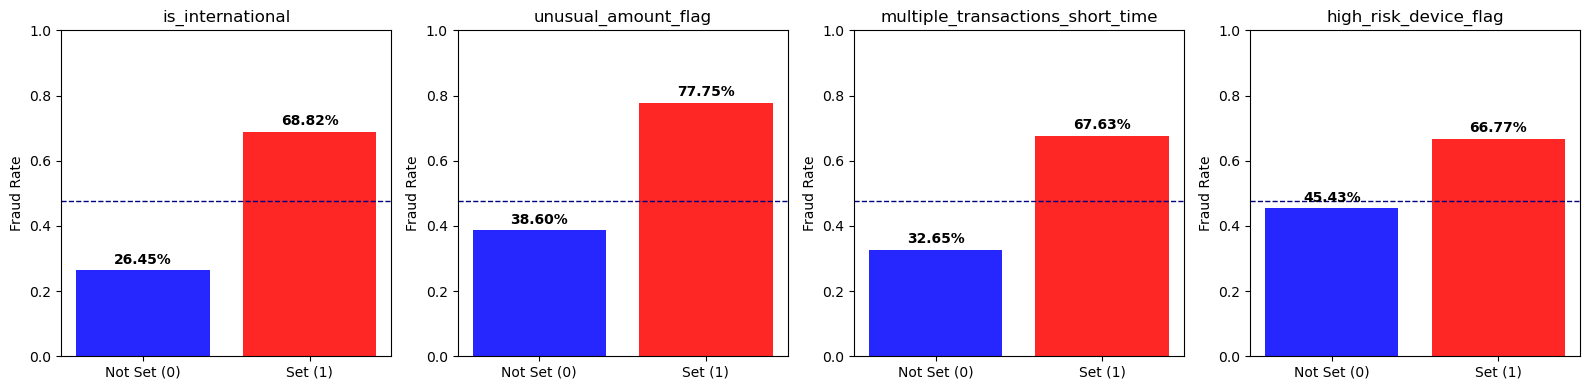

In [ ]:
flag_cols=["is_international", "unusual_amount_flag",
             "multiple_transactions_short_time", "high_risk_device_flag"]
fig, axes=plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(flag_cols):
    col_data=pd.to_numeric(df[col].astype(str).str.strip().str.lower()
                             .replace({"true": 1, "false": 0, "yes": 1, "no": 0,
                                       "y": 1, "n": 0, "1": 1, "0": 0}), errors="coerce")
    temp=pd.DataFrame({"flag": col_data, "label": df["label"]}).dropna()
    fraud_rate=temp.groupby("flag")["label"].mean()
    
    axes[i].bar(["Not Set (0)", "Set (1)"], fraud_rate, color=["blue", "red"], alpha=0.85)
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel("Fraud Rate")
    axes[i].set_ylim(0, 1)
    for j, v in enumerate(fraud_rate):
        axes[i].text(j, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")
    axes[i].axhline(df["label"].mean(), color="navy", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:
X= df.drop(columns=["label"])
y= df["label"]

split=int(len(df) * 0.85)
X_train = X.iloc[:split].copy()
y_train = y.iloc[:split].copy()

X_val = X.iloc[split:].copy()
y_val = y.iloc[split:].copy()

In [ ]:
X_train= clean_df(X_train)
X_val= clean_df(X_val)

C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\3830116874.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_international"]= df["is_international"].replace(m)
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\1041254578.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["unusual_amount_flag"]= df["unusual_amount_flag"].replace(m)
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\2040942296.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain t

In [ ]:
stats= fit_train_stats(X_train) 
X_train_clean= handle_null(X_train, stats) 
X_val_clean= handle_null(X_val,   stats)  

X_train_clean, fe_stats= advanced_feature_eng(X_train_clean, train_df=X_train_clean)
X_val_clean, _= advanced_feature_eng(X_val_clean, train_df=X_train_clean, stats=fe_stats)

X_val_clean= X_val_clean.reindex(columns=X_train_clean.columns, fill_value=0)

KeyError: "['payment_method', 'device_type', 'location', 'merchant_category'] not found in axis"

In [ ]:
X_train_clean.head()

,transaction_amount,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,unusual_amount_flag,multiple_transactions_short_time,high_risk_device_flag,transaction_amount_log,...,merchant_category_collectibles,merchant_category_electronics,merchant_category_fashion,merchant_category_gaming,merchant_category_groceries,merchant_category_luxury,merchant_category_nan,merchant_category_private seller,merchant_category_restaurants,merchant_category_travel
0,209.35,1,14.0,100.50,3.0,1499.0,1,1,0,5.348773,...,0,0,0,0,1,0,0,0,0,0
1,330.37,0,9.0,101.05,0.0,1683.0,1,1,0,5.803236,...,0,1,0,0,0,0,0,0,0,0
2,140.70,0,14.0,110.30,0.0,1058.0,1,1,0,4.953712,...,0,0,0,0,0,0,0,0,0,1
3,0.65,0,6.0,97.23,3.0,1826.0,0,0,0,0.500775,...,0,0,0,0,0,0,0,0,0,1
4,230.28,1,1.0,44.73,1.0,512.0,1,0,1,5.443629,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
tscv=TimeSeriesSplit(n_splits=5)
rd_model= RandomForestClassifier(random_state=8)
# param_grid_rf={
#     "n_estimators":range(160, 200, 10),
#     "max_depth": range(9, 11, 1),
#     "min_samples_split": range(2, 4, 1),
#     "min_samples_leaf": range(1, 3, 1)
# }
param_grid_rf= {
    "n_estimators":[160],
    "max_depth": [10],
    "min_samples_split": [2],
    "min_samples_leaf": [2],
}

rf_grid= GridSearchCV(
    estimator=rd_model,
    param_grid=param_grid_rf,
    scoring="f1",
    cv= tscv
)
rf_grid.fit(X_train_clean, y_train)
best_rf_model= rf_grid.best_estimator_

In [ ]:
val_pred= best_rf_model.predict(X_val_clean)
val_f1= f1_score(y_val, val_pred)
print("Validation F1:", val_f1)

Validation F1: 0.7681869581605729


In [ ]:
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train_clean)
X_val_scaled= scaler.transform(X_val_clean)

In [ ]:
lr_model=LogisticRegression(max_iter=25000)
param_grid_lr= {
    "C": [100, 1500, 200],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}
lr_grid= GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    scoring="f1",
    cv= tscv
)

lr_grid.fit(X_train_scaled, y_train)
best_lr_model=lr_grid.best_estimator_

In [ ]:
val_pred=best_lr_model.predict(X_val_scaled)
val_f1=f1_score(y_val, val_pred)
print("Validation F1:", val_f1)

Validation F1: 0.7768035419741297


In [ ]:
xgb_model= XGBClassifier(random_state= 8)
param_grid={
    "max_depth": range(4, 7, 1),
    "n_estimators": range(40, 50, 60),
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2]
}

# param_grid= {
#     "max_depth": [4],
#     "n_estimators": [40],
#     "learning_rate": [0.05]
# }

xgb_grid=GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1",
    cv= tscv
)

xgb_grid.fit(X_train_clean, y_train)
best_xgb_model= xgb_grid.best_estimator_

In [ ]:
val_pred= best_xgb_model.predict(X_val_clean)
val_f1= f1_score(y_val, val_pred)
print("Validation F1:", val_f1)

Validation F1: 0.7831704207394815


In [ ]:
lg_model= LGBMClassifier(objective="binary", random_state=8)
param_grid_lgbm= {
    "n_estimators": [100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "num_leaves": [16, 24, 30],
    "subsample": [0.8, 1.0]
}

# param_grid_lgbm= {
#     "n_estimators": [100],
#     "learning_rate": [0.01],
#     "max_depth": [8],
#     "num_leaves": [16],
#     "subsample": [0.8]
# }

lg_grid= GridSearchCV(
    estimator=lg_model,
    param_grid=param_grid_lgbm,
    scoring="f1",  
    n_jobs=-1,
    cv= tscv
)

lg_grid.fit(X_train_clean, y_train)
best_lg_model=lg_grid.best_estimator_

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 32429, number of negative: 35571
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4915
[LightGBM] [Info] Number of data points in the train set: 68000, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.476897 -> initscore=-0.092478
[LightGBM] [Info] Start training from score -0.092478
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [ ]:
val_pred= best_lg_model.predict(X_val_clean)
val_f1= f1_score(y_val, val_pred)
print("Validation F1:", val_f1)

Validation F1: 0.7835820895522388


In [ ]:
X_all_clean= clean_df(X.copy())
stats_all= fit_train_stats(X_all_clean)
X_all_clean= handle_null(X_all_clean, stats_all)
X_all_clean, fe_stats_all = advanced_feature_eng(X_all_clean, train_df=X_all_clean)
X_all_clean = X_all_clean.reindex(columns=X_train_clean.columns, fill_value=0)

n = len(X_all_clean)
oof_p1 = np.zeros(n) 
oof_p2 = np.zeros(n)  
oof_p3 = np.zeros(n)
oof_p4 = np.zeros(n) 
oof_true = np.zeros(n)

for train_idx, val_idx in tscv.split(X_all_clean):
    X_tr= X_all_clean.iloc[train_idx]
    X_va= X_all_clean.iloc[val_idx]
    y_tr= y.iloc[train_idx]
    y_va= y.iloc[val_idx]

    xgb_c= clone(best_xgb_model); xgb_c.fit(X_tr, y_tr)
    rf_c= clone(best_rf_model);  rf_c.fit(X_tr, y_tr)
    lg_c= clone(best_lg_model);  lg_c.fit(X_tr, y_tr)

    sc= StandardScaler()
    X_tr_s= sc.fit_transform(X_tr)
    X_va_s= sc.transform(X_va)
    lr_c= clone(best_lr_model);  lr_c.fit(X_tr_s, y_tr)

    oof_p1[val_idx]= xgb_c.predict_proba(X_va)[:, 1]
    oof_p2[val_idx]= lr_c.predict_proba(X_va_s)[:, 1]
    oof_p3[val_idx]= rf_c.predict_proba(X_va)[:, 1]
    oof_p4[val_idx]= lg_c.predict_proba(X_va)[:, 1]
    oof_true[val_idx]= y_va


C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\3830116874.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_international"]= df["is_international"].replace(m)
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\1041254578.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["unusual_amount_flag"]= df["unusual_amount_flag"].replace(m)
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\2040942296.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain t

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6484, number of negative: 6851
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4455
[LightGBM] [Info] Number of data points in the train set: 13335, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.486239 -> initscore=-0.055057
[LightGBM] [Info] Start training from score -0.055057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [ ]:
best_f1, best_w, best_threshold=-1, (0.25, 0.25, 0.25, 0.25), 0.5

for w1 in np.arange(0, 1.1, 0.1):
    for w2 in np.arange(0, 1.1 - w1, 0.1):
        for w3 in np.arange(0, 1.1 - w1 - w2, 0.1):
            w4=round(1 - w1 - w2 - w3, 10)
            if w4 < 0: continue
            oof_combined=w1*oof_p1 + w2*oof_p2 + w3*oof_p3 + w4*oof_p4
            for t in np.arange(0.3, 0.5, 0.01):
                pred= (oof_combined > t).astype(int)
                f1= f1_score(oof_true, pred)
                if f1 > best_f1:
                    best_f1=f1
                    best_w =(w1, w2, w3, w4)
                    best_threshold=t

print("Best OOF F1:", best_f1)
print("Best weights:", best_w)
print("Best threshold:", best_threshold)

Best OOF F1: 0.8155997094832953
Best weights: (np.float64(0.0), np.float64(0.1), np.float64(0.8), np.float64(0.1))
Best threshold: 0.37000000000000005


In [ ]:
xgb_probability= best_xgb_model.predict_proba(X_val_clean)[:, 1]
lr_probability= best_lr_model.predict_proba(X_val_scaled)[:, 1]
rf_probability= best_rf_model.predict_proba(X_val_clean)[:, 1]
lg_probability= best_lg_model.predict_proba(X_val_clean)[:, 1]
final_prob_val= (best_w[0]*xgb_probability +best_w[1]*lr_probability +best_w[2]*rf_probability +best_w[3]*lg_probability)

y_pred=(final_prob_val>best_threshold).astype(int)
accuracy= accuracy_score(y_val, y_pred)
precision= precision_score(y_val, y_pred)
recall= recall_score(y_val, y_pred)
f1= f1_score(y_val, y_pred)
specificity= confusion_matrix(y_val, y_pred)[0,0]/(confusion_matrix(y_val, y_pred)[0,0]+confusion_matrix(y_val, y_pred)[0,1])
roc_auc= roc_auc_score(y_val, final_prob_val)
mcc= matthews_corrcoef(y_val, y_pred)
kappa= cohen_kappa_score(y_val, y_pred)
cm= confusion_matrix(y_val, y_pred)

print("F1:", f1_score(y_val, y_pred))
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print("Matthews Corrcoef:", mcc)
print("Cohen's Kappa:", kappa)


F1: 0.8126086956521739
Accuracy: 0.7845
Precision: 0.6857876712328768
Recall (Sensitivity): 0.996977240398293
Specificity: 0.5970828105395232
F1 Score: 0.8126086956521739
ROC-AUC: 0.9119319804351667
Matthews Corrcoef: 0.6362060213214811
Cohen's Kappa: 0.5785777111826507
Confusion Matrix:
 [[3807 2569]
 [  17 5607]]


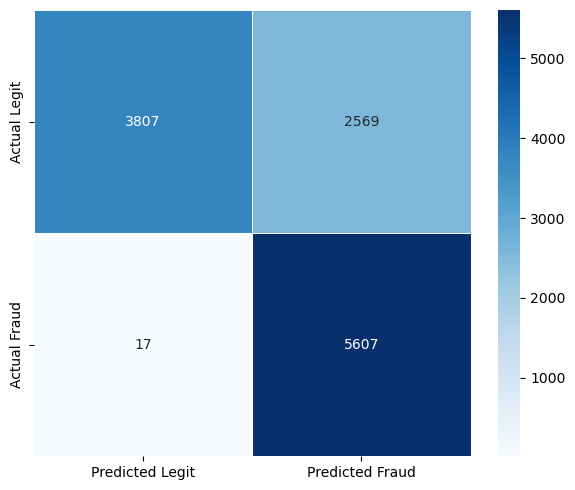

In [ ]:
fig, ax=plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Legit", "Predicted Fraud"],
            yticklabels=["Actual Legit", "Actual Fraud"],
            linewidths=0.5, ax=ax)
plt.tight_layout()
plt.show()

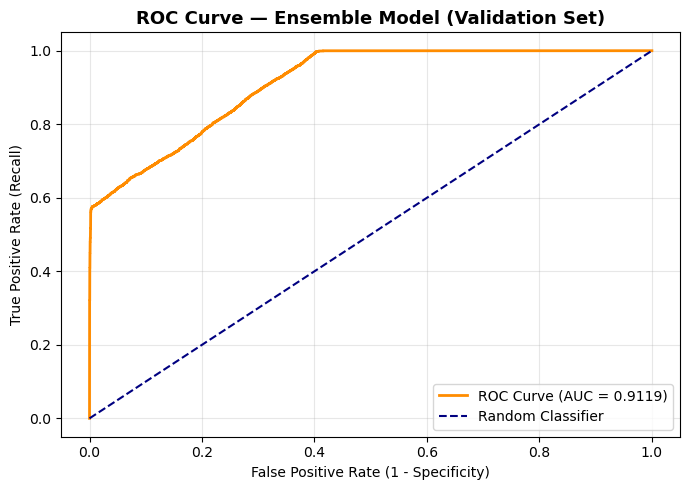

In [ ]:
fpr, tpr, _=roc_curve(y_val, final_prob_val)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Ensemble Model (Validation Set)", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

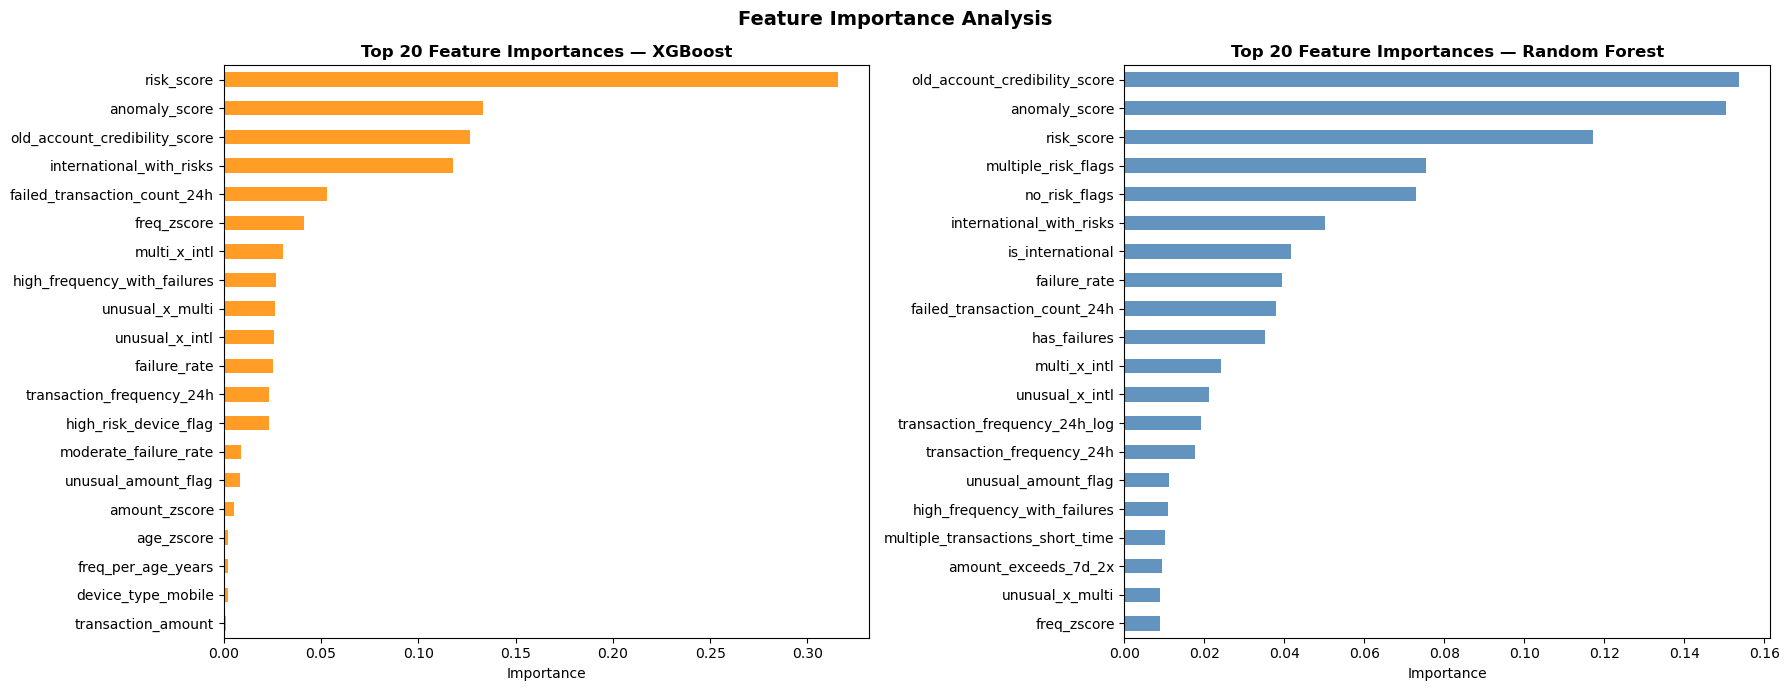

In [ ]:
fig, axes=plt.subplots(1, 2, figsize=(18, 7))

xgb_imp=pd.Series(best_xgb_model.feature_importances_, index=X_val_clean.columns)
xgb_imp.nlargest(20).sort_values().plot(kind="barh", ax=axes[0], color="darkorange", alpha=0.85)
axes[0].set_title("Top 20 Feature Importances — XGBoost", fontweight="bold")
axes[0].set_xlabel("Importance")

rf_imp= pd.Series(best_rf_model.feature_importances_, index=X_val_clean.columns)
rf_imp.nlargest(20).sort_values().plot(kind="barh", ax=axes[1], color="steelblue", alpha=0.85)
axes[1].set_title("Top 20 Feature Importances — Random Forest", fontweight="bold")
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

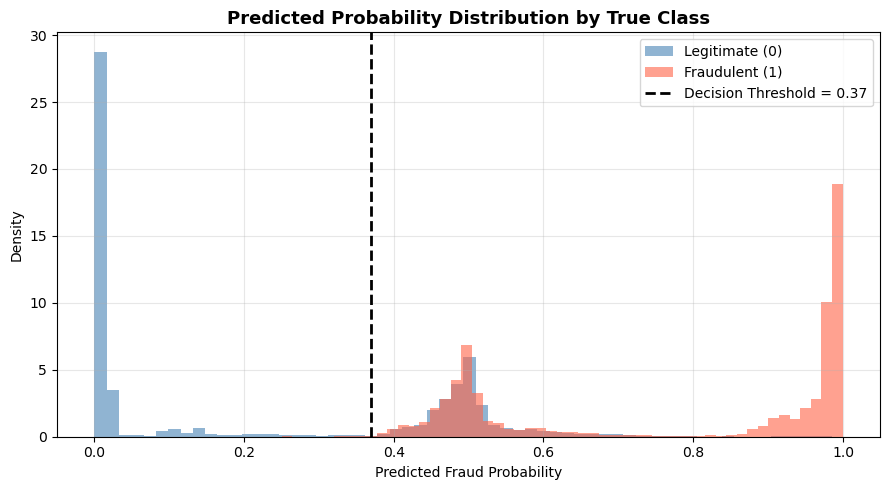

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(final_prob_val[y_val == 0], bins=60, alpha=0.6, color="steelblue",
         label="Legitimate (0)", density=True)
plt.hist(final_prob_val[y_val == 1], bins=60, alpha=0.6, color="tomato",
         label="Fraudulent (1)", density=True)
plt.axvline(best_threshold, color="black", linestyle="--", lw=2,
            label=f"Decision Threshold = {best_threshold:.2f}")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution by True Class", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_xgb_model.fit(X_all_clean, y)
best_rf_model.fit(X_all_clean, y)
best_lg_model.fit(X_all_clean, y)
scaler= StandardScaler()
X_all_scaled= scaler.fit_transform(X_all_clean)
best_lr_model.fit(X_all_scaled, y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 38053, number of negative: 41947
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4945
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475662 -> initscore=-0.097427
[LightGBM] [Info] Start training from score -0.097427
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

LogisticRegression(C=1500, max_iter=25000)

In [ ]:
df_test= pd.read_excel("task 1 - datasets/student_test.xlsx")
test_id= df_test["id"].copy()
X_test_clean= clean_df(df_test)
X_test_clean= handle_null(X_test_clean, stats_all)
X_test_clean, _ = advanced_feature_eng(X_test_clean, train_df=X_all_clean, stats=fe_stats_all)
X_test_clean= X_test_clean.reindex(columns=X_all_clean.columns, fill_value=0)
X_test_scaled= scaler.transform(X_test_clean)

xgb_p= best_xgb_model.predict_proba(X_test_clean)[:, 1]
lr_p= best_lr_model.predict_proba(X_test_scaled)[:, 1]
rf_p= best_rf_model.predict_proba(X_test_clean)[:, 1]
lg_p= best_lg_model.predict_proba(X_test_clean)[:, 1]

C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\3830116874.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_international"]= df["is_international"].replace(m)
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\1041254578.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["unusual_amount_flag"]= df["unusual_amount_flag"].replace(m)
C:\Users\alireza\AppData\Local\Temp\ipykernel_14744\2040942296.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain t

In [ ]:
final_prob= (best_w[0]*xgb_p+best_w[1]*lr_p+best_w[2]*rf_p+best_w[3]*lg_p)
prediction= (final_prob > best_threshold).astype(int)

submission= pd.DataFrame({"id": test_id, "label": prediction})
submission.to_csv("submission.csv", index=False)